# AutoEIT — Transcription Quality: v2 vs. word-probability-filtered v2 (whole dataset)

`notebooks/transcription_quality/analyze_transcription_quality.ipynb` found that for `v2` (faster-whisper), insertion-heavy
items (WER > 1) have a noticeably lower mean word probability than normal items. As a candidate
mitigation, `src/transcription/build_summary_filtered.py` rebuilds each `v2` item's transcript
keeping only words with probability > 0.6 (`summary_filtered.json`, source `v2_filtered` in the
postprocessed CSVs), and `src/postprocessing/build_postprocessed_csv.py` scores it the same way as
the other ASR sources.

An earlier version of this notebook split the 84 hit recordings into train/val/test and only read
train+val, on the theory that the 0.6 probability threshold was something being tuned and shouldn't
be evaluated on data used to pick it. In practice no such tuning process exists — 0.6 was a single
ad hoc choice, not searched over a validation set — so held-out splitting bought nothing but fewer
recordings per estimate. This version scores all 84 hit recordings at once
(`data/transcribed_v2_hit_recordings.txt`).

## Metrics: WER, MER, and CER

- **WER (Word Error Rate)** = (S + D + I) / N, where N is the number of words in the reference.
  Standard ASR metric; unbounded above 1.0 when there are many insertions relative to the reference.
- **MER (Match Error Rate)** = (S + D + I) / (S + D + C + I). Same edit counts as WER, but the
  denominator includes correct words too, so MER is always in [0, 1] — it doesn't blow up the way
  WER can on insertion-heavy output.
- **CER (Character Error Rate)** — the same idea as WER but computed over characters instead of
  words. It's more forgiving of near-miss spelling/inflection errors (e.g. "manejar" vs "manejer"
  costs 1 substitution in WER but a fraction of a "word" in CER), and is less sensitive to how
  tokenization splits words, so it's a useful cross-check when WER and MER disagree.

All three are computed after lowercasing and stripping punctuation, against each human rater
separately.

## Config

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
POSTPROCESSED_ROOT = Path("../../data/postprocessed/v2")
VERSIONS = ["version_a", "version_b"]
ASR_SOURCES = ["v2", "v2_filtered", "parakeet", "wav2vec2"]
RATERS = ["rater1", "rater2"]
METRICS = ["wer", "mer", "cer"]

hit_recordings = set(Path("../../data/transcribed_v2_hit_recordings.txt").read_text(encoding="utf-8").split())
print(f"{len(hit_recordings)} hit recordings")

84 hit recordings


## Load per-item scores

One tidy row per (recording, sentence, ASR source, rater), across all hit recordings.

In [3]:
def load_scores(recording_names: set[str]) -> pd.DataFrame:
    records = []
    for version in VERSIONS:
        version_dir = POSTPROCESSED_ROOT / version
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_dir.name not in recording_names:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            for source in ASR_SOURCES:
                for rater in RATERS:
                    cols = [f"{source}_{m}_{rater}" for m in METRICS]
                    if cols[0] not in df.columns:
                        continue
                    sub = df[["sentence_number", *cols]].dropna()
                    for _, row in sub.iterrows():
                        records.append({
                            "version": version,
                            "recording": recording_dir.name,
                            "sentence_number": row["sentence_number"],
                            "source": source,
                            "rater": rater,
                            "wer": row[cols[0]],
                            "mer": row[cols[1]],
                            "cer": row[cols[2]],
                        })
    return pd.DataFrame(records)


scores = load_scores(hit_recordings)
n_rec = scores["recording"].nunique()
print(f"{len(scores)} scored items, {n_rec} recordings")

19668 scored items, 82 recordings


## Human floor

For context, the inter-rater agreement floor (rater1 vs. rater2, same scoring, see
`analyze_interrater_agreement.ipynb` for the full writeup) over this same 84-recording set, shown
alongside the ASR systems below.

In [4]:
def load_human_scores(recording_names: set[str]) -> pd.DataFrame:
    records = []
    for version in VERSIONS:
        version_dir = POSTPROCESSED_ROOT / version
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_dir.name not in recording_names:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            if "human_wer" not in df.columns:
                continue
            sub = df[["sentence_number", "human_wer", "human_mer", "human_cer"]].dropna()
            for _, row in sub.iterrows():
                records.append({
                    "version": version,
                    "recording": recording_dir.name,
                    "sentence_number": row["sentence_number"],
                    "source": "human",
                    "rater": "rater1_vs_rater2",
                    "wer": row["human_wer"],
                    "mer": row["human_mer"],
                    "cer": row["human_cer"],
                })
    return pd.DataFrame(records)


human_scores = load_human_scores(hit_recordings)
scores_with_human = pd.concat([scores, human_scores], ignore_index=True)
print(f"human floor: {len(human_scores)} scored sentences")

human floor: 2460 scored sentences


In [5]:
source_colors = {"v2": "#4C72B0", "v2_filtered": "#8172B2", "parakeet": "#DD8452", "wav2vec2": "#55A868", "human": "#777777"}
DISPLAY_SOURCES = ASR_SOURCES + ["human"]


def summarize(scores: pd.DataFrame, order: list[str] = ASR_SOURCES) -> pd.DataFrame:
    mean_tbl = scores.groupby("source")[METRICS].mean().round(4).reindex(order)
    median_tbl = scores.groupby("source")[METRICS].median().round(4).reindex(order)
    pct_perfect = scores.groupby("source")["wer"].apply(lambda x: (x == 0).mean()).round(3).reindex(order)
    out = mean_tbl.add_suffix("_mean").join(median_tbl.add_suffix("_median"))
    out["wer_pct_perfect"] = pct_perfect
    return out


def plot_metrics(scores: pd.DataFrame, title: str, save_path: str, order: list[str] = ASR_SOURCES) -> None:
    summary = scores.groupby("source")[METRICS].mean().reindex(order)
    x = np.arange(len(order))
    width = 0.25

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, metric in enumerate(METRICS):
        offset = (i - 1) * width
        bars = ax.bar(x + offset, summary[metric], width, label=metric.upper())
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width() / 2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.set_ylabel("Mean error rate")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

## Whole dataset (n=84, both raters), ASR vs. human floor

In [6]:
summarize(scores_with_human, order=DISPLAY_SOURCES)

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
v2,0.2521,0.2159,0.1460,0.1429,0.1429,0.0435,0.369
v2_filtered,0.2644,0.2461,0.1854,0.1667,0.1667,0.0833,0.313
parakeet,0.2713,0.2502,0.1514,0.1429,0.1429,0.0476,0.346
wav2vec2,0.3126,0.2888,0.1495,0.2500,0.2222,0.0714,0.224
human,0.1517,0.1417,0.0722,0.1000,0.1000,0.0238,0.447


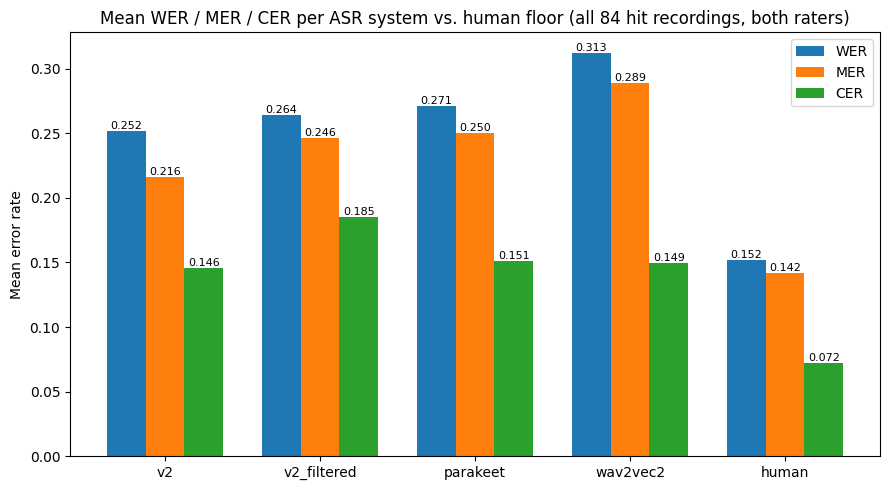

In [7]:
plot_metrics(scores_with_human, "Mean WER / MER / CER per ASR system vs. human floor (all 84 hit recordings, both raters)",
             "../plots/transcription_quality_metrics.png", order=DISPLAY_SOURCES)

## v2 vs. v2_filtered, side by side

In [8]:
comparison = scores[scores["source"].isin(["v2", "v2_filtered"])].groupby("source")[METRICS].mean().round(4)
comparison

,wer,mer,cer
source,,,
v2,0.2521,0.2159,0.1460
v2_filtered,0.2644,0.2461,0.1854


**Result: filtering out words with probability ≤ 0.6 makes things worse, not better, on every
metric.**

A blanket per-word confidence filter removes more correctly-transcribed-but-naturally-uncertain
words (turning them into deletions) than it removes genuine hallucinated insertions. Net effect —
WER/MER/CER all go up, and CER in particular gets hit hardest, consistent with whole words
disappearing rather than being replaced by near-miss spellings.

This doesn't kill the underlying idea (v2's low-confidence words *do* concentrate in
insertion-heavy items, per the correlation in `analyze_transcription_quality.ipynb`) — it means a
blanket "keep words above X%" filter is the wrong shape of intervention. A more targeted version
worth trying next: only trim low-confidence words from segments that are already suspiciously long
relative to the item's expected duration/word count (i.e. target the insertion-heavy items
specifically), or trim from the edges rather than throughout.